# Emotion Detection in Sinhala Language Texts in Social Media
## By 2021/E/045 and 2021/E053

In [ ]:
#!pip install --upgrade -r requirements.txt

In [25]:
from transformers import pipeline

pipe = pipeline("fill-mask", model="NLPC-UOM/SinBERT-large")
from transformers import AutoTokenizer, AutoModelForMaskedLM

tokenizer = AutoTokenizer.from_pretrained("NLPC-UOM/SinBERT-large")
model = AutoModelForMaskedLM.from_pretrained("NLPC-UOM/SinBERT-large")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
from nltk.metrics.agreement import AnnotationTask


In [27]:
dataset_path = "../raw/4_labeled.csv"
df = pd.read_csv(dataset_path, encoding='utf-8')
df = df.rename(columns={
    'Annotator 1': 'emotion_1',
    'Annotator 2': 'emotion_2',
    'Annotator 3': 'emotion_3',
    'Annotator 4': 'emotion_4',
    'Phrase': 'text'
})
df = df.loc[:, ~df.columns.str.contains(r'^NaN')]
print(f"Loaded {len(df)} rows with columns: {df.columns.tolist()}")


Loaded 11288 rows with columns: ['emotion_1', 'emotion_2', 'emotion_3', 'emotion_4', 'text']


In [28]:
df.head()

,emotion_1,emotion_2,emotion_3,emotion_4,text
0,joy,joy,joy,joy,නියම සිංහල මහත්මයෙක්.
1,joy,joy,joy,joy,අන්න මිනිස්සු...
2,disgust,anger,NaN,anger,හොරා හොද මිනිහෙක් නම් අනේ මහත්තයෝ සමාවෙන්න කිය...
3,NaN,NaN,NaN,NaN,තව ඩිංගෙන් ලබු ගෙඩියත් කොස් ගෙඩි සහ පොල් ගෙඩි ...
4,NaN,disgust,disgust,disgust,"බතල වැලට, කොස්ගෙඩි අටට, උසාවි ගිහින් රිමන්ඩ් ක..."


## Data Preprocessing

### Changing the data type of the columns

In [29]:
rater_cols = ['emotion_1', 'emotion_2', 'emotion_3', 'emotion_4']

for col in rater_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({'nan': np.nan, '': np.nan})

print(df.dtypes)
print(f"\nMissing votes per annotator:\n{df[rater_cols].isna().sum()}")


emotion_1    str
emotion_2    str
emotion_3    str
emotion_4    str
text         str
dtype: object

Missing votes per annotator:
emotion_1    6538
emotion_2    6133
emotion_3    6299
emotion_4    6051
dtype: int64


In [30]:
df.head()

,emotion_1,emotion_2,emotion_3,emotion_4,text
0,joy,joy,joy,joy,නියම සිංහල මහත්මයෙක්.
1,joy,joy,joy,joy,අන්න මිනිස්සු...
2,disgust,anger,NaN,anger,හොරා හොද මිනිහෙක් නම් අනේ මහත්තයෝ සමාවෙන්න කිය...
3,NaN,NaN,NaN,NaN,තව ඩිංගෙන් ලබු ගෙඩියත් කොස් ගෙඩි සහ පොල් ගෙඩි ...
4,NaN,disgust,disgust,disgust,"බතල වැලට, කොස්ගෙඩි අටට, උසාවි ගිහින් රිමන්ඩ් ක..."


### Fleiss' Kappa (Multi-Annotator Inter-Rater Agreement)

In [31]:
from sklearn.metrics import cohen_kappa_score
import itertools

kappa_scores = []
for col1, col2 in itertools.combinations(rater_cols, 2):
    mask = df[col1].notna() & df[col2].notna()
    if mask.sum() > 1:
        k = cohen_kappa_score(df.loc[mask, col1], df.loc[mask, col2])
        kappa_scores.append(k)
        print(f"  {col1} vs {col2}: κ={k:.4f}  (n={mask.sum()})")

if kappa_scores:
    avg_kappa = np.mean(kappa_scores)
    print(f"\nAverage pairwise Cohen's Kappa: {avg_kappa:.4f}")
    if avg_kappa < 0.2:
        print("Agreement level: Slight")
    elif avg_kappa < 0.4:
        print("Agreement level: Fair")
    elif avg_kappa < 0.6:
        print("Agreement level: Moderate")
    elif avg_kappa < 0.8:
        print("Agreement level: Substantial")
    else:
        print("Agreement level: Almost Perfect")
else:
    print("No annotation pairs found.")


  emotion_1 vs emotion_2: κ=0.9642  (n=4292)
  emotion_1 vs emotion_3: κ=0.9845  (n=4528)
  emotion_1 vs emotion_4: κ=0.9619  (n=4319)
  emotion_2 vs emotion_3: κ=0.9653  (n=4506)
  emotion_2 vs emotion_4: κ=0.9967  (n=5123)
  emotion_3 vs emotion_4: κ=0.9618  (n=4535)

Average pairwise Cohen's Kappa: 0.9724
Agreement level: Almost Perfect


In [32]:
for col in rater_cols:
    df[col] = df[col].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip().str.lower()
    df[col] = df[col].replace({'nan': np.nan, '': np.nan})


In [33]:
for col in rater_cols:
    counts = df[col].value_counts(dropna=True)
    print(f"{col}:\n{counts}\n")


emotion_1:
emotion_1
fear        1270
surprise     915
joy          906
disgust      610
sadness      607
anger        442
Name: count, dtype: int64

emotion_2:
emotion_2
fear        1286
joy          996
surprise     936
disgust      679
sadness      650
anger        607
j              1
Name: count, dtype: int64

emotion_3:
emotion_3
fear        1260
joy          939
surprise     893
disgust      724
sadness      641
anger        532
Name: count, dtype: int64

emotion_4:
emotion_4
fear        1289
joy         1030
surprise     945
disgust      691
sadness      664
anger        618
Name: count, dtype: int64



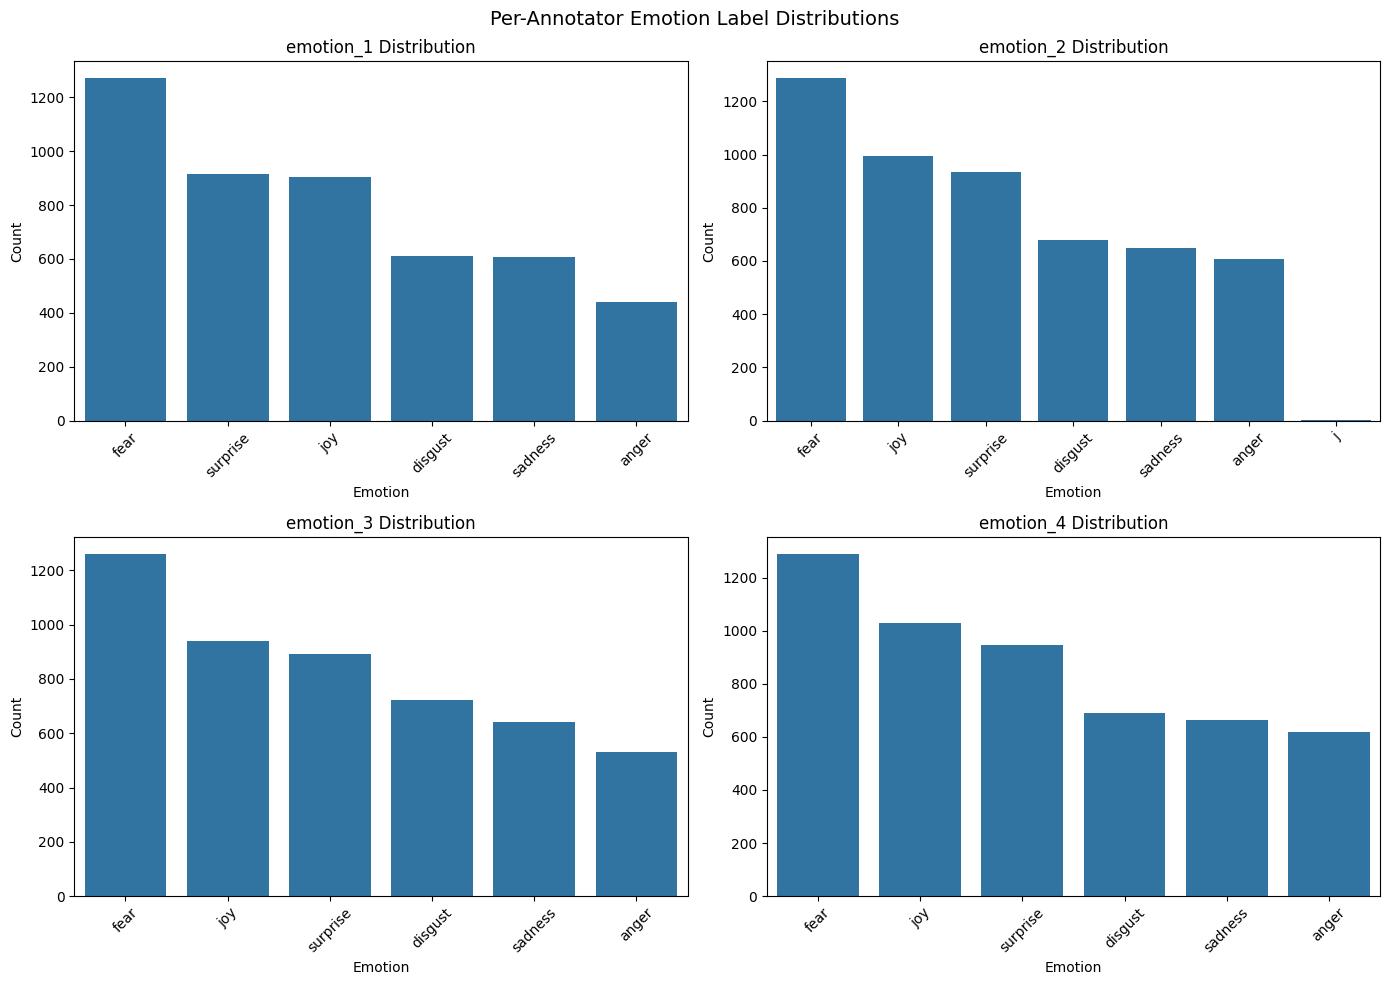

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(rater_cols):
    counts = df[col].value_counts(dropna=True)
    sns.barplot(x=counts.index.tolist(), y=counts.values, ax=axes[i])
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Emotion')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle('Per-Annotator Emotion Label Distributions', fontsize=14)
plt.tight_layout()
plt.show()


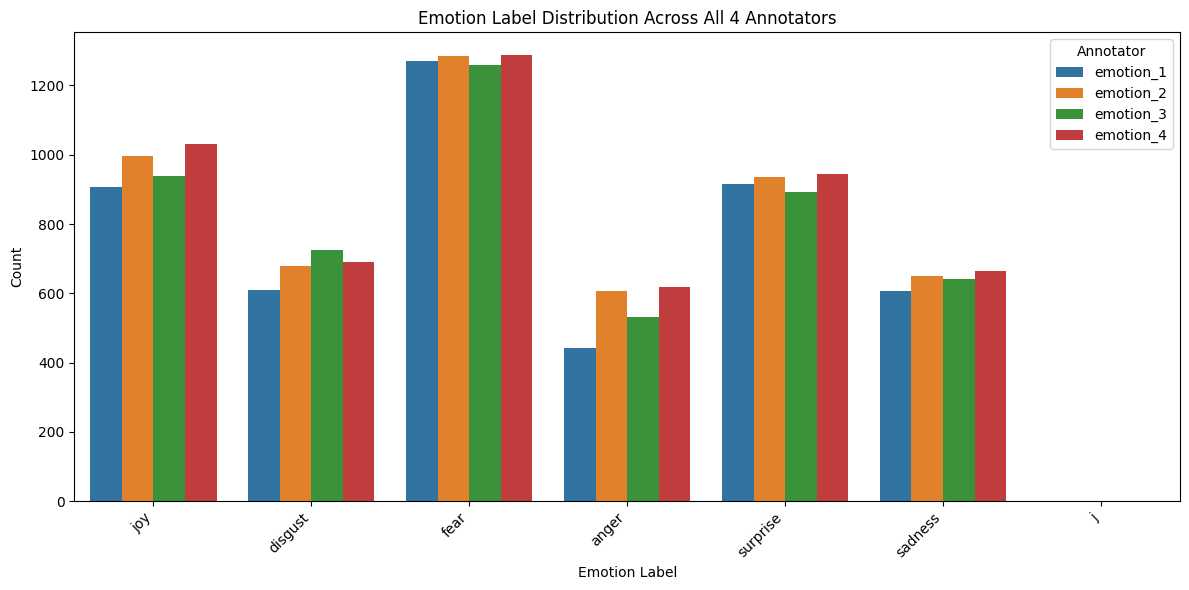

In [35]:
dataset_melted = df[rater_cols].melt(var_name='Annotator', value_name='Annotation').dropna()

plt.figure(figsize=(12, 6))
sns.countplot(data=dataset_melted, x='Annotation', hue='Annotator')
plt.title('Emotion Label Distribution Across All 4 Annotators')
plt.xlabel('Emotion Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [36]:
vote_summary = []
for _, row in df.iterrows():
    votes = [row[c] for c in rater_cols if pd.notna(row[c])]
    n_votes = len(votes)
    if n_votes == 0:
        agreement = 'no_votes'
    else:
        top_count = max(Counter(votes).values())
        if top_count == n_votes:
            agreement = 'unanimous'
        elif top_count >= 3:
            agreement = 'majority_3+'
        elif top_count == 2 and n_votes == 4:
            agreement = 'split_2-2'
        elif top_count == 2:
            agreement = 'majority_2'
        else:
            agreement = 'no_majority'
    vote_summary.append(agreement)

df['_vote_type'] = vote_summary
print("Vote agreement breakdown:")
print(df['_vote_type'].value_counts())
df = df.drop(columns=['_vote_type'])


Vote agreement breakdown:
_vote_type
unanimous      5712
no_votes       5384
split_2-2        70
majority_2       47
majority_3+      47
no_majority      28
Name: count, dtype: int64


## Token Length Distribution

In [37]:
df = df.drop_duplicates()

# Optionally, reset the index after dropping duplicates
df = df.reset_index(drop=True)

In [38]:
df = df.dropna(subset=rater_cols, how='all').reset_index(drop=True)
print(f"Rows after dropping all-empty annotator rows: {len(df)}")


Rows after dropping all-empty annotator rows: 4379


In [39]:
df['_vote_count'] = df[rater_cols].notna().sum(axis=1)
print(f"Vote count distribution:\n{df['_vote_count'].value_counts().sort_index()}")
df = df[df['_vote_count'] >= 2].reset_index(drop=True)
df = df.drop(columns=['_vote_count'])
print(f"\nRows with ≥2 annotator votes: {len(df)}")
df.head()


Vote count distribution:
_vote_count
1     483
2     869
3     275
4    2752
Name: count, dtype: int64

Rows with ≥2 annotator votes: 3896


,emotion_1,emotion_2,emotion_3,emotion_4,text
0,joy,joy,joy,joy,නියම සිංහල මහත්මයෙක්.
1,joy,joy,joy,joy,අන්න මිනිස්සු...
2,disgust,anger,NaN,anger,හොරා හොද මිනිහෙක් නම් අනේ මහත්තයෝ සමාවෙන්න කිය...
3,NaN,disgust,disgust,disgust,"බතල වැලට, කොස්ගෙඩි අටට, උසාවි ගිහින් රිමන්ඩ් ක..."
4,joy,NaN,joy,NaN,ගොවි මහත්තයාගේ ගෙවත්තේ ලබු වැලේ ගෙඩි 50ක් පමණ ...


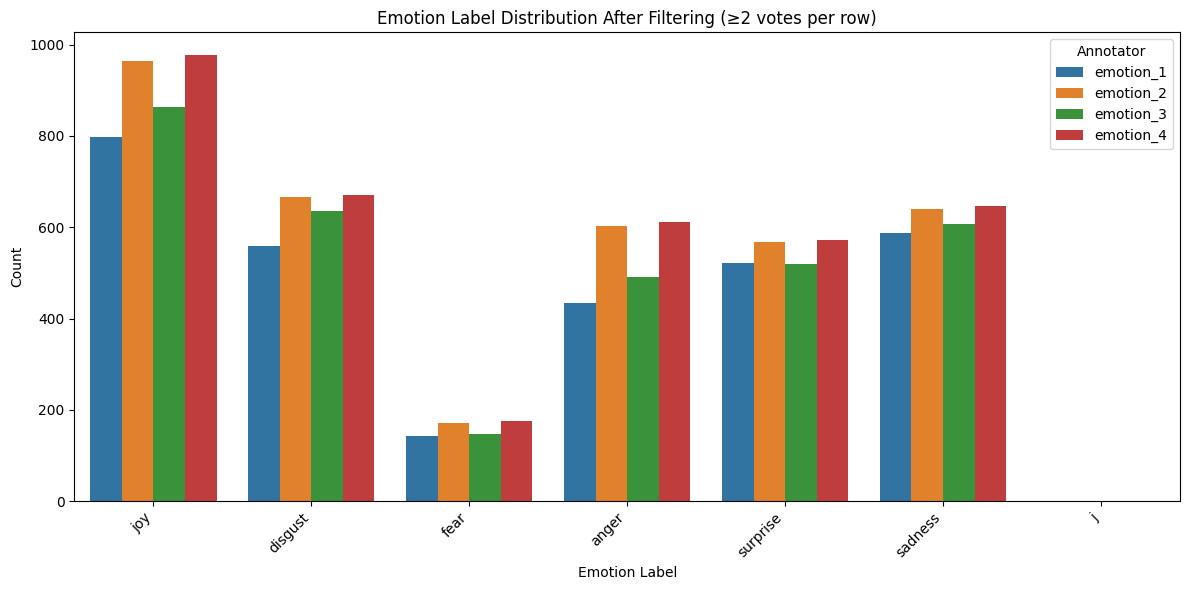

In [40]:
dataset_melted = df[rater_cols].melt(var_name='Annotator', value_name='Annotation').dropna()

plt.figure(figsize=(12, 6))
sns.countplot(data=dataset_melted, x='Annotation', hue='Annotator')
plt.title('Emotion Label Distribution After Filtering (≥2 votes per row)')
plt.xlabel('Emotion Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [41]:
def majority_vote(row):
    votes = [row[c] for c in rater_cols if pd.notna(row[c])]
    if not votes:
        return np.nan
    counts = Counter(votes)
    top_count = max(counts.values())
    top_labels = [label for label, cnt in counts.items() if cnt == top_count]
    if len(top_labels) > 1:
        return np.nan  # tie → drop
    return top_labels[0]

df['label'] = df.apply(majority_vote, axis=1)
total = len(df)
kept = df['label'].notna().sum()
print(f"Majority vote applied: {kept} rows with clear majority, {total - kept} ties/empties dropped.")

df = df.dropna(subset=['label']).reset_index(drop=True)
df = df[['text', 'label']]
df.head()


Majority vote applied: 3800 rows with clear majority, 96 ties/empties dropped.


,text,label
0,නියම සිංහල මහත්මයෙක්.,joy
1,අන්න මිනිස්සු...,joy
2,හොරා හොද මිනිහෙක් නම් අනේ මහත්තයෝ සමාවෙන්න කිය...,anger
3,"බතල වැලට, කොස්ගෙඩි අටට, උසාවි ගිහින් රිමන්ඩ් ක...",disgust
4,ගොවි මහත්තයාගේ ගෙවත්තේ ලබු වැලේ ගෙඩි 50ක් පමණ ...,joy


In [42]:
df.head()

,text,label
0,නියම සිංහල මහත්මයෙක්.,joy
1,අන්න මිනිස්සු...,joy
2,හොරා හොද මිනිහෙක් නම් අනේ මහත්තයෝ සමාවෙන්න කිය...,anger
3,"බතල වැලට, කොස්ගෙඩි අටට, උසාවි ගිහින් රිමන්ඩ් ක...",disgust
4,ගොවි මහත්තයාගේ ගෙවත්තේ ලබු වැලේ ගෙඩි 50ක් පමණ ...,joy


In [46]:
df['label'] = df['label'].replace(['', 'nan', 'NaN'], np.nan)
df = df.dropna(subset=['label']).reset_index(drop=True)

label_counts = df['label'].value_counts()
valid_labels = label_counts[label_counts >= 10].index
df = df[df['label'].isin(valid_labels)].reset_index(drop=True)
print(f"Dataset after filtering small classes (< 10 samples): {len(df)} rows")
print(df['label'].value_counts())


Dataset after filtering small classes (< 10 samples): 3800 rows
label
joy         1050
disgust      720
sadness      679
anger        597
surprise     576
fear         178
Name: count, dtype: int64


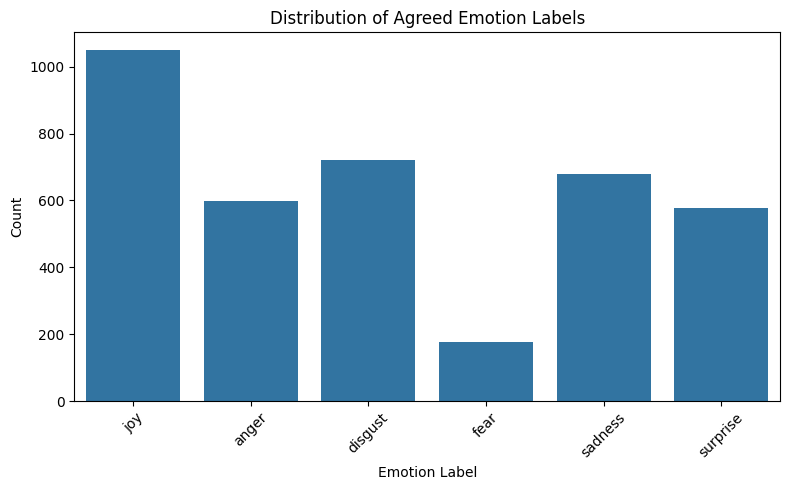

In [45]:

plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df)
plt.title('Distribution of Agreed Emotion Labels')
plt.xlabel('Emotion Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
# Check the number of samples for each class in the 'label' column
print(df['label'].value_counts())

label
joy         1050
disgust      720
sadness      679
anger        597
surprise     576
fear         178
Name: count, dtype: int64


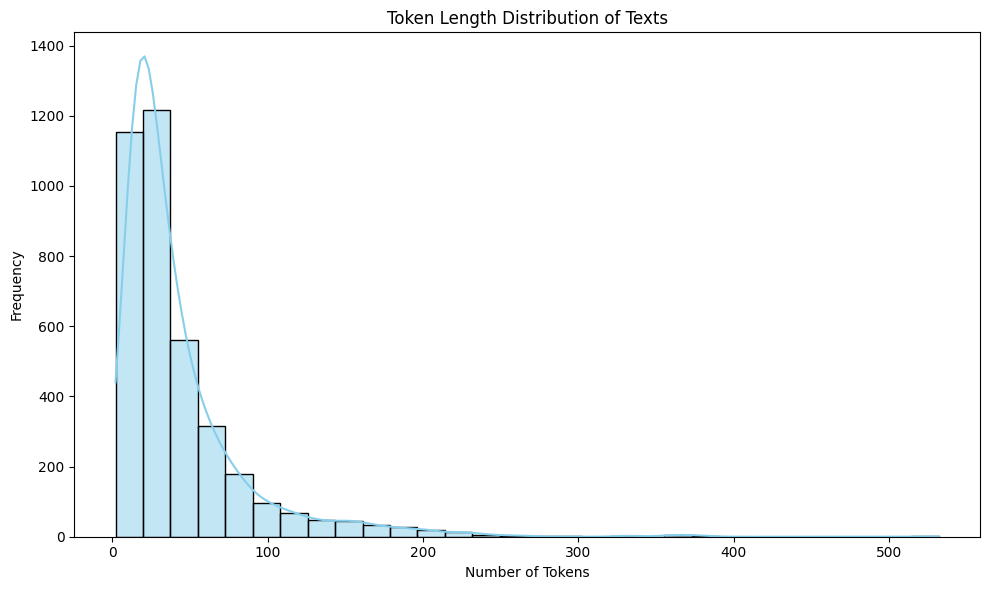

In [49]:
df['token_length'] = df['text'].apply(lambda x: len(tokenizer.tokenize(str(x))))

# 2. Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['token_length'], bins=30, kde=True, color='skyblue')
plt.title('Token Length Distribution of Texts')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
df.drop(columns=['token_length'], inplace=True)  # Clean up the DataFrame


In [50]:
import os
os.makedirs('./processed', exist_ok=True)
df.to_csv('./processed/processed_dataset.csv', index=False, encoding='utf-8')
print(f"Saved {len(df)} rows to ./New_DataSet_Models/processed/processed_dataset.csv")


Saved 3800 rows to ./New_DataSet_Models/processed/processed_dataset.csv
